In [1]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from gensim.models import FastText
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
actual = pd.read_csv(r"C:\Users\TITAN\Desktop\New folder (2)\netflix_titles.csv")

In [3]:
actual.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df = actual.copy()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


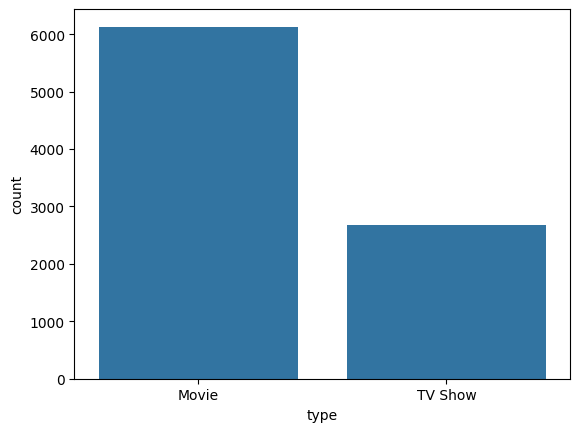

In [5]:
df["type"].value_counts(dropna=False)
print(df["type"].value_counts(dropna=False))
df["type"].unique()
df["type"].value_counts(normalize=True) * 100
sns.countplot(data=df, x="type")
plt.show()

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
df.isna().sum()


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [8]:
df.groupby("type").apply(lambda x: x.isna().sum())


C:\Users\TITAN\AppData\Local\Temp\ipykernel_20568\3131709060.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("type").apply(lambda x: x.isna().sum())


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
type,,,,,,,,,,,,
Movie,0,0,0,188,475,440,0,0,2,3,0,0
TV Show,0,0,0,2446,350,391,10,0,2,0,0,0


In [9]:
df = df[~((df["type"] == "Movie") & df.isna().any(axis=1))]


In [10]:
movie_idx = df[df["type"] == "Movie"].sample(frac=0.45, random_state=42).index
df = df.drop(movie_idx)

type
Movie      2852
TV Show    2676
Name: count, dtype: int64


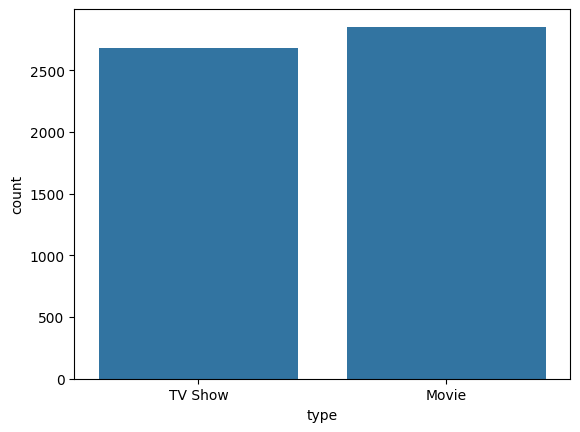

In [11]:
df["type"].value_counts(dropna=False)
print(df["type"].value_counts(dropna=False))
df["type"].unique()
df["type"].value_counts(normalize=True) * 100
sns.countplot(data=df, x="type")
plt.show()

In [12]:
df["type"] = df["type"].map({"Movie": 0, "TV Show": 1})

df["date_added"] = pd.to_datetime(df["date_added"].str.strip())

df["date"] = df["date_added"].dt.day.astype("Int64")
df["month"] = df["date_added"].dt.month.astype("Int64")
df["year"] = df["date_added"].dt.year.astype("Int64")



In [13]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,date,month,year
1,s2,1,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021
2,s3,1,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,24,9,2021
3,s4,1,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",24,9,2021
4,s5,1,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,24,9,2021
5,s6,1,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,24,9,2021


In [14]:
df["rating"].unique()


array(['TV-MA', 'TV-14', 'PG-13', 'TV-Y7', 'PG', 'R', 'TV-PG', 'TV-Y',
       'TV-G', 'G', 'NC-17', 'NR', 'TV-Y7-FV', nan, 'UR'], dtype=object)

In [15]:
rating_score = {
    "G": 1,
    "TV-G": 1,
    "PG": 2,
    "TV-PG": 2,
    "PG-13": 3,
    "TV-14": 3,
    "TV-Y": 1,
    "TV-Y7": 2,
    "TV-Y7-FV": 2,
    "TV-MA": 4,
    "R": 4,
    "NR": 3,
    "UR": 3
}
df["rating"] = df["rating"].str.strip()

df["rating"] = df["rating"].map(rating_score).fillna(0).astype("Int64")


In [16]:
df["show_id"] = df["show_id"].str.extract(r"(\d+)")[0]
df["show_id"] = pd.to_numeric(df["show_id"])


In [17]:
df["duration"] = df["duration"].str.extract(r"(\d+)")[0]
df["duration"] = pd.to_numeric(df["duration"])


In [18]:
df["country"] = df["country"].fillna("").str.count(",") + 1


In [19]:
df = df.drop(columns=["date_added"])


In [20]:
df.head()

,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in,description,date,month,year
1,2,1,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",1,2021,4,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021
2,3,1,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",1,2021,4,1,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,24,9,2021
3,4,1,Jailbirds New Orleans,NaN,NaN,1,2021,4,1,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",24,9,2021
4,5,1,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",1,2021,4,2,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,24,9,2021
5,6,1,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",1,2021,4,1,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,24,9,2021


In [21]:
director_freq = df["director"].value_counts(normalize=True)

df["director"] = df["director"].map(director_freq).fillna(0)


In [22]:

# Keep missing values as an empty list
df["listed_in"] = df["listed_in"].fillna("")

mlb = MultiLabelBinarizer()

listed_in_encoded = mlb.fit_transform(
    df["listed_in"].str.split(", ")
)

listed_in_df = pd.DataFrame(
    listed_in_encoded,
    columns=["genre_" + col for col in mlb.classes_],
    index=df.index
)

df = pd.concat([df, listed_in_df], axis=1)

In [23]:
df = df.drop(columns=["listed_in"])


In [24]:
df.head()

,show_id,type,title,director,cast,country,release_year,rating,duration,description,...,genre_TV Action & Adventure,genre_TV Comedies,genre_TV Dramas,genre_TV Horror,genre_TV Mysteries,genre_TV Sci-Fi & Fantasy,genre_TV Shows,genre_TV Thrillers,genre_Teen TV Shows,genre_Thrillers
1,2,1,Blood & Water,0.000000,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",1,2021,4,2,"After crossing paths at a party, a Cape Town t...",...,0,0,1,0,1,0,0,0,0,0
2,3,1,Ganglands,0.000973,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",1,2021,4,1,To protect his family from a powerful drug lor...,...,1,0,0,0,0,0,0,0,0,0
3,4,1,Jailbirds New Orleans,0.000000,NaN,1,2021,4,1,"Feuds, flirtations and toilet talk go down amo...",...,0,0,0,0,0,0,0,0,0,0
4,5,1,Kota Factory,0.000000,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",1,2021,4,2,In a city of coaching centers known to train I...,...,0,1,0,0,0,0,0,0,0,0
5,6,1,Midnight Mass,0.001298,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",1,2021,4,1,The arrival of a charismatic young priest brin...,...,0,0,1,1,1,0,0,0,0,0


In [25]:
df["description"] = df["description"].fillna("").str.lower()

# Tokenize descriptions
sentences = df["description"].apply(str.split).tolist()

# Train FastText
model = FastText(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4
)

# Convert each movie description into one vector
def encode(text):
    words = text.split()
    vectors = [model.wv[word] for word in words if word in model.wv]

    if len(vectors) == 0:
        return np.zeros(100)

    return np.mean(vectors, axis=0)

df["description"] = df["description"].apply(encode)

In [26]:
# Fill missing cast values
df["cast"] = df["cast"].fillna("")

# Clean cast names
df["cast"] = (
    df["cast"]
    .str.strip()
    .str.replace(r"\s*,\s*", ",", regex=True)
)

# TF-IDF
tfidf_cast = TfidfVectorizer(
    tokenizer=lambda x: x.split(","),
    token_pattern=None,
    lowercase=True
)

# Convert cast into TF-IDF matrix
cast_tfidf = tfidf_cast.fit_transform(df["cast"])

In [27]:
df["user_id"] = np.random.randint(
    1,
    1001,
    size=len(df)
)

In [28]:
df.head()

,show_id,type,title,director,cast,country,release_year,rating,duration,description,...,genre_TV Comedies,genre_TV Dramas,genre_TV Horror,genre_TV Mysteries,genre_TV Sci-Fi & Fantasy,genre_TV Shows,genre_TV Thrillers,genre_Teen TV Shows,genre_Thrillers,user_id
1,2,1,Blood & Water,0.000000,"Ama Qamata,Khosi Ngema,Gail Mabalane,Thabang M...",1,2021,4,2,"[-0.42800653, 1.1120157, -0.89717066, -0.15890...",...,0,1,0,1,0,0,0,0,0,596
2,3,1,Ganglands,0.000973,"Sami Bouajila,Tracy Gotoas,Samuel Jouy,Nabiha ...",1,2021,4,1,"[-0.39773643, 1.0313138, -0.8275539, -0.149722...",...,0,0,0,0,0,0,0,0,0,738
3,4,1,Jailbirds New Orleans,0.000000,,1,2021,4,1,"[-0.37154022, 0.96380854, -0.7671904, -0.14198...",...,0,0,0,0,0,0,0,0,0,536
4,5,1,Kota Factory,0.000000,"Mayur More,Jitendra Kumar,Ranjan Raj,Alam Khan...",1,2021,4,2,"[-0.42822108, 1.1119441, -0.8915601, -0.161208...",...,1,0,0,0,0,0,0,0,0,998
5,6,1,Midnight Mass,0.001298,"Kate Siegel,Zach Gilford,Hamish Linklater,Henr...",1,2021,4,1,"[-0.41294944, 1.071319, -0.86093557, -0.155666...",...,0,1,1,1,0,0,0,0,0,430


In [29]:
df["user_id"].nunique()


999

In [34]:
df.to_csv(r"C:\Users\TITAN\Desktop\Recomentation_system\data\raw\netflix_preprocessed.csv")